In [1]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print('Data loaded and preprocessed successfully.')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded and preprocessed successfully.


In [2]:
# Define Model
model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

# Compile Model
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

# Fit Model
history1 = model1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))

# Summary
model1.summary()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.8926 - loss: 0.3899 - val_acc: 0.9416 - val_loss: 0.2084
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9469 - loss: 0.1868 - val_acc: 0.9548 - val_loss: 0.1579
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9590 - loss: 0.1427 - val_acc: 0.9612 - val_loss: 0.1371
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9668 - loss: 0.1164 - val_acc: 0.9663 - val_loss: 0.1156
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9721 - loss: 0.0974 - val_acc: 0.9691 - val_loss: 0.1060
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9753 - loss: 0.0846 - val_acc: 0.9697 - val_loss: 0.0995
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9790 - loss: 0.0742 - val_acc: 0.9690 - val_loss: 0.0980
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9812 - loss: 0.0648 - val_acc: 0.9733 - val_loss: 0.0887
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - ac

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9733 - loss: 0.0878
Akurasi Testing ANN: 0.9732999801635742


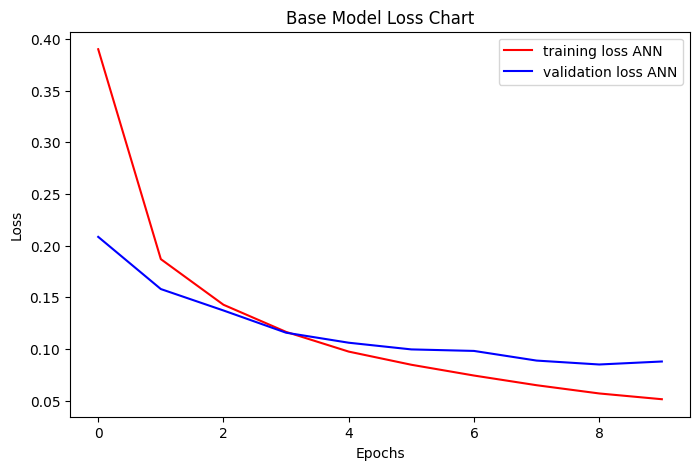

In [3]:
# Evaluate Model
loss, accuracy = model1.evaluate(X_test, y_test)
print('Akurasi Testing ANN:', accuracy)

# Plot Loss Chart
epochs = range(10)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss1, 'r', label='training loss ANN')
plt.plot(epochs, val_loss1, 'b', label='validation loss ANN')
plt.title('Base Model Loss Chart')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7976 - loss: 2.6712 - val_acc: 0.8432 - val_loss: 1.2355
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8458 - loss: 1.1602 - val_acc: 0.8558 - val_loss: 1.0733
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.8551 - loss: 1.0404 - val_acc: 0.8671 - val_loss: 0.9746
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8615 - loss: 0.9765 - val_acc: 0.8733 - val_loss: 0.9212
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8641 - loss: 0.9341 - val_acc: 0.8756 - val_loss: 0.8745
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8687 - loss: 0.8980 - val_acc: 0.8806 - val_loss: 0.8654
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.8708 - loss: 0.8732 - val_acc: 0.8761 - val_loss: 0.8335
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8729 - loss: 0.8557 - val_acc: 0.8811 - val_loss: 0.8093
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8869 - loss: 0.7842
Akurasi Testing ANN (L1): 0.886900007724762


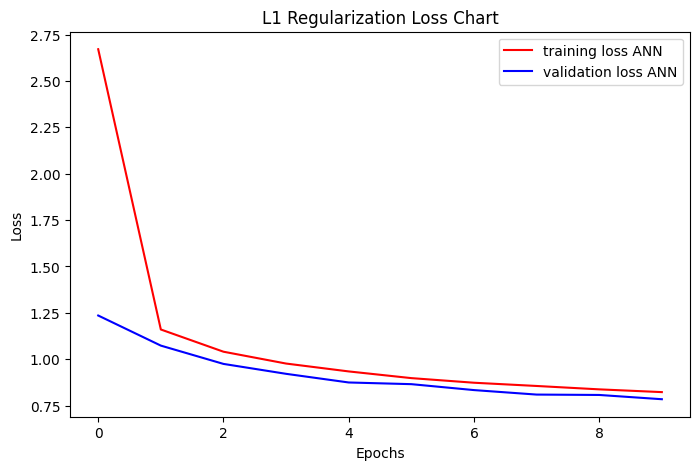

In [4]:
# Define Model with L1 Regularization
model_l1 = Sequential()
model_l1.add(Flatten())
model_l1.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(0.01)))
model_l1.add(Dense(10, activation='softmax'))

# Compile and Fit
model_l1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history_l1 = model_l1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))

# Summary
model_l1.summary()

# Evaluate
loss_l1, acc_l1 = model_l1.evaluate(X_test, y_test)
print('Akurasi Testing ANN (L1):', acc_l1)

# Plot Loss Chart
epochs = range(10)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_l1.history['loss'], 'r', label='training loss ANN')
plt.plot(epochs, history_l1.history['val_loss'], 'b', label='validation loss ANN')
plt.title('L1 Regularization Loss Chart')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.8822 - loss: 0.7271 - val_acc: 0.9226 - val_loss: 0.4534
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.9214 - loss: 0.4302 - val_acc: 0.9278 - val_loss: 0.3965
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9300 - loss: 0.3809 - val_acc: 0.9336 - val_loss: 0.3551
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9353 - loss: 0.3517 - val_acc: 0.9453 - val_loss: 0.3251
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9408 - loss: 0.3260 - val_acc: 0.9474 - val_loss: 0.3056
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9442 - loss: 0.3100 - val_acc: 0.9500 - val_loss: 0.2889
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9472 - loss: 0.2952 - val_acc: 0.9517 - val_loss: 0.2760
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9503 - loss: 0.2824 - val_acc: 0.9539 - val_loss: 0.2606
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9579 - loss: 0.2502
Akurasi Testing ANN (L2): 0.9578999876976013


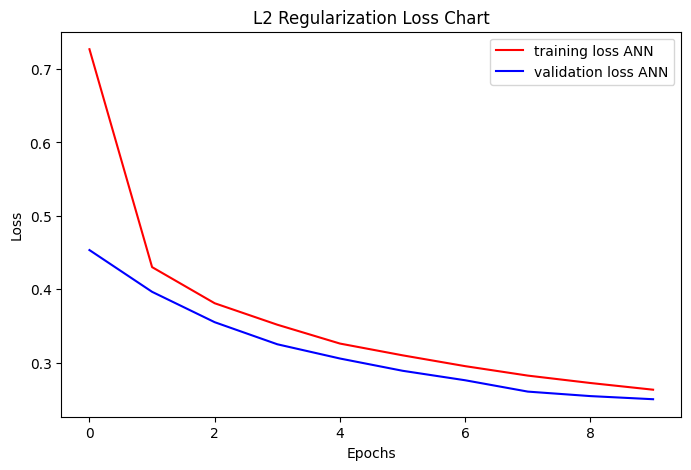

In [5]:
# Define Model with L2 Regularization
model_l2 = Sequential()
model_l2.add(Flatten())
model_l2.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_l2.add(Dense(10, activation='softmax'))

# Compile and Fit
model_l2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history_l2 = model_l2.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))

# Summary
model_l2.summary()

# Evaluate
loss_l2, acc_l2 = model_l2.evaluate(X_test, y_test)
print('Akurasi Testing ANN (L2):', acc_l2)

# Plot Loss Chart
epochs = range(10)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_l2.history['loss'], 'r', label='training loss ANN')
plt.plot(epochs, history_l2.history['val_loss'], 'b', label='validation loss ANN')
plt.title('L2 Regularization Loss Chart')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8107 - loss: 0.6259 - val_acc: 0.9265 - val_loss: 0.2587
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8941 - loss: 0.3630 - val_acc: 0.9399 - val_loss: 0.2029
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9066 - loss: 0.3145 - val_acc: 0.9469 - val_loss: 0.1759
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9142 - loss: 0.2878 - val_acc: 0.9531 - val_loss: 0.1605
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9203 - loss: 0.2683 - val_acc: 0.9574 - val_loss: 0.1484
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9240 - loss: 0.2553 - val_acc: 0.9572 - val_loss: 0.1411
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9272 - loss: 0.2403 - val_acc: 0.9596 - val_loss: 0.1376
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9296 - loss: 0.2330 - val_acc: 0.9616 - val_loss: 0.1311
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9646 - loss: 0.1236
Akurasi Testing ANN (Dropout): 0.9646000266075134


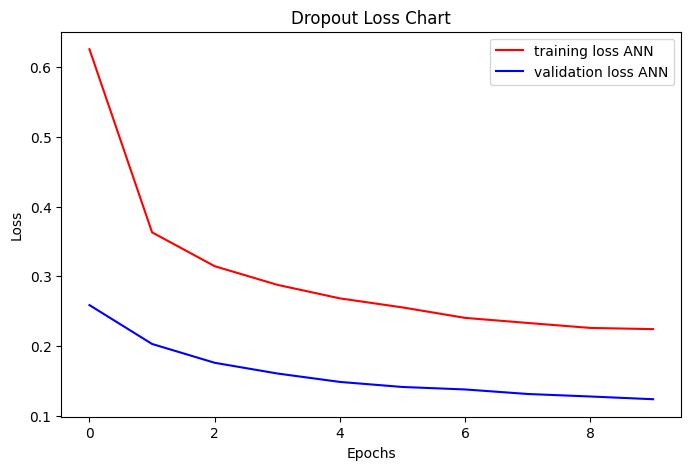

In [6]:
# Define Model with Dropout
model_dropout = Sequential()
model_dropout.add(Flatten())
model_dropout.add(Dense(64, activation='relu'))
model_dropout.add(Dropout(0.5)) # Dropout rate 50%
model_dropout.add(Dense(10, activation='softmax'))

# Compile and Fit
model_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history_dropout = model_dropout.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))

# Summary
model_dropout.summary()

# Evaluate
loss_drop, acc_drop = model_dropout.evaluate(X_test, y_test)
print('Akurasi Testing ANN (Dropout):', acc_drop)

# Plot Loss Chart
epochs = range(10)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_dropout.history['loss'], 'r', label='training loss ANN')
plt.plot(epochs, history_dropout.history['val_loss'], 'b', label='validation loss ANN')
plt.title('Dropout Loss Chart')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.8924 - loss: 0.3909 - val_acc: 0.9345 - val_loss: 0.2223
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9456 - loss: 0.1921 - val_acc: 0.9532 - val_loss: 0.1621
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9583 - loss: 0.1460 - val_acc: 0.9601 - val_loss: 0.1347
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9662 - loss: 0.1187 - val_acc: 0.9619 - val_loss: 0.1211
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9715 - loss: 0.0996 - val_acc: 0.9658 - val_loss: 0.1108
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9758 - loss: 0.0843 - val_acc: 0.9681 - val_loss: 0.1023
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9784 - loss: 0.0735 - val_acc: 0.9700 - val_loss: 0.0940
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9813 - loss: 0.0643 - val_acc: 0.9726 - val_loss: 0.0880
Epoch 9/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9754 - loss: 0.0820
Akurasi Testing ANN (Early Stopping): 0.9753999710083008


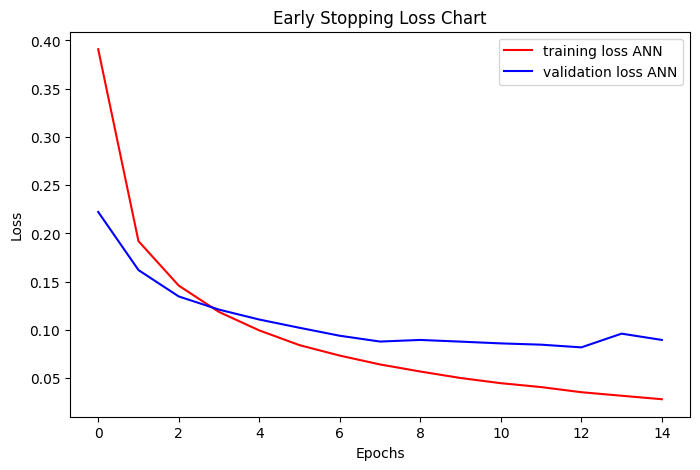

In [7]:
# Define Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Define Model
model_es = Sequential()
model_es.add(Flatten())
model_es.add(Dense(64, activation='relu'))
model_es.add(Dense(10, activation='softmax'))

# Compile and Fit with Early Stopping
model_es.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
# Note: Epochs increased to 20 to allow early stopping to trigger
history_es = model_es.fit(X_train, y_train, epochs=20, batch_size=100, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Summary
model_es.summary()

# Evaluate
loss_es, acc_es = model_es.evaluate(X_test, y_test)
print('Akurasi Testing ANN (Early Stopping):', acc_es)

# Plot Loss Chart
epochs = range(len(history_es.history['loss']))
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_es.history['loss'], 'r', label='training loss ANN')
plt.plot(epochs, history_es.history['val_loss'], 'b', label='validation loss ANN')
plt.title('Early Stopping Loss Chart')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.6457 - loss: 2.9767 - val_acc: 0.8321 - val_loss: 1.4248
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.7269 - loss: 1.5213 - val_acc: 0.8515 - val_loss: 1.2658
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.7499 - loss: 1.4224 - val_acc: 0.8549 - val_loss: 1.1924
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.7658 - loss: 1.3617 - val_acc: 0.8594 - val_loss: 1.1693
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.7752 - loss: 1.3261 - val_acc: 0.8707 - val_loss: 1.1092
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.7793 - loss: 1.3077 - val_acc: 0.8571 - val_loss: 1.1100
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7853 - loss: 1.2816 - val_acc: 0.8843 - val_loss: 1.0266
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7914 - loss: 1.2586 - val_acc: 0.8809 - val_loss: 1.0333
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - ac

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (100, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (100, 64)              │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (100, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (100, 10)              │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8850 - loss: 1.0225
Akurasi Testing ANN (L1 + Dropout): 0.8849999904632568


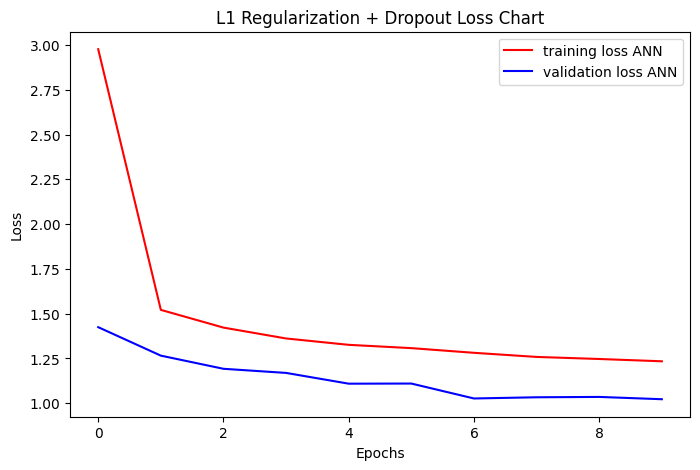

In [8]:
# Define Model with L1 Regularization and Dropout
model_l1_dropout = Sequential()
model_l1_dropout.add(Flatten())
model_l1_dropout.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(0.01)))
model_l1_dropout.add(Dropout(0.5)) # Dropout rate 50%
model_l1_dropout.add(Dense(10, activation='softmax'))

# Compile and Fit
model_l1_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history_l1_dropout = model_l1_dropout.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))

# Summary
model_l1_dropout.summary()

# Evaluate
loss_l1_drop, acc_l1_drop = model_l1_dropout.evaluate(X_test, y_test)
print('Akurasi Testing ANN (L1 + Dropout):', acc_l1_drop)

# Plot Loss Chart
epochs = range(10)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_l1_dropout.history['loss'], 'r', label='training loss ANN')
plt.plot(epochs, history_l1_dropout.history['val_loss'], 'b', label='validation loss ANN')
plt.title('L1 Regularization + Dropout Loss Chart')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()